# **DATA 6400 Final Project Robust Fake Review Detection with Large Language Models: A Prompt Rewording and Review Length Analysis**

## Jose Barral, Victoria González, Arjun Moitra & Ooreoluwa Ayoola
## April 10th, 2026

Acknowledgments:
* We used ChatGPT for some syntax guidance and all instances of this are commented appropriately below.
* All other programming, text explanations and analysis are our own.

## 1. Imports and Setup

First, we need to download an older version of numpy in order to be able to use the hugging face dataset.

In [ ]:
!pip -q uninstall -y numpy pandas datasets transformers

!pip install -U transformers accelerate evaluate

!pip -q uninstall -y numpy pandas datasets transformers
!pip -q install --no-cache-dir numpy==1.26.4 pandas==2.2.2 datasets==2.18.0
!pip -q install --no-cache-dir "transformers @ git+https://github.com/huggingface/transformers.git@main"
!pip -q install --no-cache-dir accelerate bitsandbytes sentencepiece scikit-learn matplotlib tqdm
!pip install -U transformers accelerate evaluate

print("Installed clean versions. Restart the runtime now, then continue.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 11.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2

ERROR: Operation cancelled by user
^C
^C
^C
^C


Libraries Needed:

In [2]:
# Dataset Import
import datasets
from datasets import load_dataset

# Data Handling
import pandas as pd
import numpy as np

# System / Memory
import os
import gc

# Tokenization
from collections import Counter
from transformers import AutoTokenizer

# Progress bar
from tqdm.auto import tqdm

# Parsing
import re

# Modeling
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Graphs
import seaborn as sns
import matplotlib.pyplot as plt

# Google Drive (Saving of results)
from google.colab import drive

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["HF_HOME"] = "/content/drive/MyDrive/huggingface_cache"
os.makedirs(os.environ["HF_HOME"], exist_ok=True)

print("HF cache:", os.environ["HF_HOME"])
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("No GPU found. Enable a T4 GPU in Runtime → Change runtime type.")

HF cache: /content/drive/MyDrive/huggingface_cache
CUDA available: True
GPU: Tesla T4


Then, we load the hugging face dataset.

In [ ]:
print(datasets.__version__)

#Load of hugging face dataset
ds = load_dataset("difraud/difraud", "product_reviews", trust_remote_code=True)
ds

As shown, the dataset is already split into training, validation, and test sets, containing 16,776, 2,097, and 2,098 observations, respectively.

## 2. Data Quality Check

In [ ]:
train_df = pd.DataFrame(ds["train"])
val_df   = pd.DataFrame(ds["validation"])
test_df  = pd.DataFrame(ds["test"])

train_df.head()

,text,label
0,J. D Salinger was righteous... Not in his scri...,1
1,"Take my word, this is one of the best grill co...",1
2,"As other reviewers have mentioned, the packagi...",0
3,Great bookcase for small space and is sturdy e...,0
4,It's ok... I pirchased this thinking it'd male...,0


In [ ]:
# Any null values?
print(train_df.isnull().sum())

# Class balance?
print(train_df["label"].value_counts())
print(train_df["label"].value_counts(normalize=True))

# Basic length
train_df["text_length"] = train_df["text"].str.len()
print(train_df["text_length"].describe())

text     0
label    0
dtype: int64
label
1    8393
0    8383
Name: count, dtype: int64
label
1    0.500298
0    0.499702
Name: proportion, dtype: float64
count    16776.000000
mean       361.855269
std        460.182063
min         62.000000
25%        154.000000
50%        233.000000
75%        381.000000
max      15957.000000
Name: text_length, dtype: float64


The dataset shows no missing values in either the text or label variables, indicating that it is complete and ready for modeling.

In terms of class distribution, the dataset is perfectly balanced, with 8,393 instances labeled as 1 and 8,383 as 0. This corresponds to proportions of 50.03% and 49.97%, respectively, ensuring no class imbalance issues that could bias the model.

Regarding text length, there is significant variability across reviews. The average length is approximately 362 characters, with a median of 233, indicating a right-skewed distribution. The shortest review contains 62 characters, while the longest reaches 15,957 characters. The interquartile range (154 to 381 characters) shows that most reviews are relatively short, although the presence of very long outliers suggests that truncation during tokenization could be necessary.

## 3. Length Analysis

We analyze the token lengths to define a balanced categorization of reviews into short, medium, and long groups.

In [ ]:
#For this, we will use the Roberta base tokenizer
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def count_tokens(example):
    tokens = tokenizer.tokenize(example["text"])
    example["n_tokens"] = len(tokens) + 2
    return example

ds = ds.map(count_tokens)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/16776 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (593 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/2097 [00:00<?, ? examples/s]

Map:   0%|          | 0/2098 [00:00<?, ? examples/s]

In [ ]:
train_lengths = ds["train"]["n_tokens"]

q1 = np.quantile(train_lengths, 0.33)
q2 = np.quantile(train_lengths, 0.66)

print("Q1:", q1)
print("Q2:", q2)

Q1: 42.0
Q2: 71.0


Then, reviews are categorized as follows: short (≤ 42 tokens), medium (43–71 tokens), and long (> 71 tokens).

In [ ]:
train_df["length_tokens"] = train_df["text"].apply(lambda x: len(x.split()))

# Short review
short_example = train_df.sort_values("length_tokens").iloc[0]["text"]

# Long review
long_example = train_df.sort_values("length_tokens", ascending=False).iloc[0]["text"]

print("SHORT REVIEW:\n", short_example)
print("\nLONG REVIEW:\n", long_example)

SHORT REVIEW:
 Quality GOOD! BUT Slightly larger size. Poodle ( 10-15 lbs ) XS Recommended!

LONG REVIEW:
 The first Darksiders told a great story and had fantastic gameplay to accompany. Darksiders 2 continues the great story, but the gameplay is an enormous let down. There's much more of an RPG feel, as you can level up and explore a skill tree to develop your own style of play unlike the first game. You can collect random items dropped by monsters and "feed" normal items to "possessed" items in order to power them up. This is where the fun ends. The game is mostly played through combat, and the combat is poorly executed. Because of the random quality of the items that enemies drop, the attributes you take into combat are a grab bag at any given time and they rarely work for whatever monster you happen to come across. Pausing gameplay to switch your equipment to make up for this is just a disaster. It takes the pure adrenaline right out of the gameplay and just dumbs it down to... I 

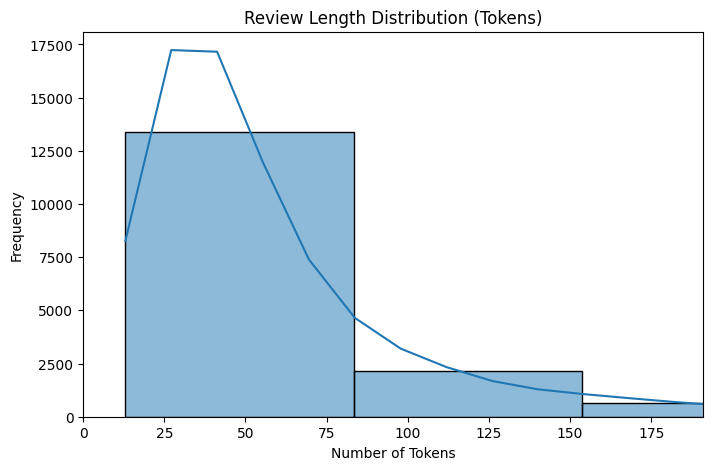

In [ ]:
p95 = train_df["length_tokens"].quantile(0.95)

plt.figure(figsize=(8,5))
sns.histplot(train_df["length_tokens"], bins=40, kde=True)
plt.xlim(0, p95)
plt.title("Review Length Distribution (Tokens)")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()

Then, we create the length groups based on the previously identified quantile thresholds.

In [ ]:
def assign_length_group(example):
    if example["n_tokens"] <= q1:
        example["length_group"] = "short"
    elif example["n_tokens"] <= q2:
        example["length_group"] = "medium"
    else:
        example["length_group"] = "long"
    return example

ds = ds.map(assign_length_group)

Map:   0%|          | 0/16776 [00:00<?, ? examples/s]

Map:   0%|          | 0/2097 [00:00<?, ? examples/s]

Map:   0%|          | 0/2098 [00:00<?, ? examples/s]

In [ ]:
print("Train:", Counter(ds["train"]["length_group"]))
print("Validation:", Counter(ds["validation"]["length_group"]))
print("Test:", Counter(ds["test"]["length_group"]))

Train: Counter({'long': 5666, 'short': 5622, 'medium': 5488})
Validation: Counter({'long': 731, 'medium': 696, 'short': 670})
Test: Counter({'long': 722, 'short': 699, 'medium': 677})


## 4. Models

### 4.1. Roberta Model

We will use Roberta as the baseline model.

#### 4.1.1. Model architecture

We tokenize the input text using the RoBERTa tokenizer. Truncation and padding are applied to a maximum sequence length of 512 tokens to ensure uniform input size across all samples.

In [ ]:
def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

ds_tokenized = ds.map(tokenize, batched=True)

Map:   0%|          | 0/16776 [00:00<?, ? examples/s]

Map:   0%|          | 0/2097 [00:00<?, ? examples/s]

Map:   0%|          | 0/2098 [00:00<?, ? examples/s]

After tokenization, the original text column is removed, and the label column is renamed to match the expected input format (labels). The dataset is then converted to PyTorch tensors for model training.

In [ ]:
ds_tokenized = ds_tokenized.remove_columns(["text"])
ds_tokenized = ds_tokenized.rename_column("label", "labels")

ds_tokenized.set_format("torch")

A pre-trained RoBERTa-base model is loaded for sequence classification, with a binary output layer (num_labels = 2) corresponding to the FAKE/REAL classification task.

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model performance is evaluated using accuracy, precision, recall, and F1-score. Predictions are obtained by selecting the class with the highest logit score. Given the nature of the task, recall is used as the main metric for model selection to prioritize the detection of fake reviews.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

Evaluation and model saving are performed at the end of each epoch, and the best model is selected based on recall. Weight decay is applied to improve generalization.

In [ ]:
training_args = TrainingArguments(
    output_dir="./roberta_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="recall",
    greater_is_better=True,
    report_to="none",
    disable_tqdm=True
)

Then, the Hugging Face Trainer is used to manage the training and evaluation process by integrating the model, training arguments, datasets, and evaluation metrics into a unified pipeline.

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_tokenized["train"],
    eval_dataset=ds_tokenized["validation"],
    compute_metrics=compute_metrics
)

#### 4.1.2. Model training

In [ ]:
trainer.train()

{'loss': '0.6375', 'grad_norm': '6.986', 'learning_rate': '1.524e-05', 'epoch': '0.4766'}
{'loss': '0.5849', 'grad_norm': '16.68', 'learning_rate': '1.048e-05', 'epoch': '0.9533'}
{'eval_loss': '0.5762', 'eval_accuracy': '0.7067', 'eval_precision': '0.7754', 'eval_recall': '0.5825', 'eval_f1': '0.6652', 'eval_runtime': '61.25', 'eval_samples_per_second': '34.24', 'eval_steps_per_second': '2.155', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.5104', 'grad_norm': '9.82', 'learning_rate': '5.71e-06', 'epoch': '1.43'}
{'loss': '0.4967', 'grad_norm': '10.35', 'learning_rate': '9.438e-07', 'epoch': '1.907'}
{'eval_loss': '0.5743', 'eval_accuracy': '0.7225', 'eval_precision': '0.7132', 'eval_recall': '0.7445', 'eval_f1': '0.7285', 'eval_runtime': '61.39', 'eval_samples_per_second': '34.16', 'eval_steps_per_second': '2.15', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

{'train_runtime': '3407', 'train_samples_per_second': '9.848', 'train_steps_per_second': '0.616', 'train_loss': '0.5539', 'epoch': '2'}


TrainOutput(global_step=2098, training_loss=0.5538772186628401, metrics={'train_runtime': 3407.1581, 'train_samples_per_second': 9.848, 'train_steps_per_second': 0.616, 'train_loss': 0.5538772186628401, 'epoch': 2.0})

#### 4.1.3. Model evaluation

In [ ]:
test_metrics = trainer.evaluate(eval_dataset=ds_tokenized["test"])
print(test_metrics)

{'eval_loss': '0.5696', 'eval_accuracy': '0.7193', 'eval_precision': '0.7006', 'eval_recall': '0.7667', 'eval_f1': '0.7322', 'eval_runtime': '62.33', 'eval_samples_per_second': '33.66', 'eval_steps_per_second': '2.118', 'epoch': '2'}
{'eval_loss': 0.5696370005607605, 'eval_accuracy': 0.719256434699714, 'eval_precision': 0.700609225413403, 'eval_recall': 0.7666666666666667, 'eval_f1': 0.7321509777171441, 'eval_runtime': 62.3305, 'eval_samples_per_second': 33.659, 'eval_steps_per_second': 2.118, 'epoch': 2.0}


In [ ]:
# Test predictions
pred_output = trainer.predict(ds_tokenized["test"])
pred_labels = pred_output.predictions.argmax(axis=1)
true_labels = pred_output.label_ids

# Unify with original dataset
test_results_df = pd.DataFrame(ds["test"])
test_results_df["pred_label"] = pred_labels
test_results_df["true_label"] = true_labels

# Metrics by group
group_metrics = []

for group in ["short", "medium", "long"]:
    subset = test_results_df[test_results_df["length_group"] == group]

    y_true = subset["true_label"]
    y_pred = subset["pred_label"]

    group_metrics.append({
        "length_group": group,
        "n": len(subset),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    })

group_metrics_df = pd.DataFrame(group_metrics)
print(group_metrics_df)

  length_group    n  accuracy  precision    recall        f1
0        short  699  0.698140   0.644699  0.721154  0.680787
1       medium  677  0.704579   0.727848  0.829327  0.775281
2         long  722  0.753463   0.720859  0.729814  0.725309


Since the primary objective of this study is to maximize recall, we focus on the model’s ability to correctly identify deceptive reviews. The results show that recall varies across review length groups. Medium-length reviews achieved the highest recall (0.829), indicating that the model successfully identifies a large proportion of deceptive reviews in this category. In comparison, recall decreases for long reviews (0.729) and short reviews (0.721). This suggests that reviews of moderate length provide the most informative signals for detecting deception, while very short reviews lack sufficient context and very long reviews may introduce additional noise.

#### 4.1.4. Saving of results

In [ ]:
drive.mount('/content/drive')

In [ ]:
#Final metrics of model
group_metrics_df.to_csv(
"/content/drive/MyDrive/roberta_metrics_by_length.csv",
index=False
)

In [ ]:
#Test prediction
test_results_df.to_csv(
"/content/drive/MyDrive/roberta_test_predictions.csv",
index=False
)

In [ ]:
#Trained model
trainer.save_model("/content/drive/MyDrive/roberta_fake_review_model")

#If we need it, just run:
#from transformers import AutoModelForSequenceClassification

#model = AutoModelForSequenceClassification.from_pretrained(
#"/content/drive/MyDrive/roberta_fake_review_model"
#)

### 4.2. Mistral Model

#### 4.2.1. Model setup

We use the Mistral-7B-Instruct model for zero-shot classification. The model is loaded using the Hugging Face Transformers library, along with its corresponding tokenizer. To optimize performance, half-precision (float16) is used when a GPU is available, and the model is automatically distributed across devices using device_map="auto".

In [ ]:
model_id = "mistralai/Mistral-7B-Instruct-v0.3"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

#### 4.2.1. Prompt design and rewording

The task is framed as a zero-shot classification problem, where each review is embedded into a prompt instructing the model to classify it as FAKE or REAL. Different prompt variations are tested to evaluate their impact on performance.

In [ ]:
prompt_A = """Classify this product review as FAKE or REAL.

A REAL review usually reflects genuine product experience, including concrete details, natural wording, or personal usage.
A FAKE review often relies on vague praise, exaggerated enthusiasm, or promotional language without clear evidence of real use.

Output exactly one word:
FAKE
or
REAL

Review:
{review}
"""

prompt_B = """Classify this product review as FAKE or REAL.

Consider whether it reflects genuine product experience or vague promotional language.

Output exactly one word:
FAKE
or
REAL

Review:
{review}
"""

prompt_C = """Classify this product review as FAKE or REAL.

Use cues such as specific experience, vague praise, and promotional wording.

Output exactly one word:
FAKE
or
REAL

Review:
{review}
"""

In [ ]:
prompts = {
    "prompt_A": prompt_A,
    "prompt_B": prompt_B,
    "prompt_C": prompt_C
}

#### 4.2.2. Inference and Output parsing

During inference, each review is embedded into a structured prompt and passed to the model using a chat-based format. The model generates a short textual response, which is constrained to a maximum of a few tokens to ensure concise outputs.

Since the model is generative, the raw output must be processed to extract a valid prediction. Therefore, the generated response is decoded, trimmed, and parsed to obtain a clean label (FAKE or REAL), ensuring consistency across predictions.

In [ ]:
def classify_review(review_text, prompt_template):

    messages = [
        {
            "role": "system",
            "content": (
                "You are a product review classifier. "
                "Classify each review as FAKE or REAL. "
                "Output only one word. "
                "Allowed outputs: FAKE or REAL. "
                "Do not explain. "
                "Do not add punctuation. "
                "Do not add extra text."
            )
        },
        {
            "role": "user",
            "content": prompt_template.format(review=review_text)
        }
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    outputs = model.generate(
        **inputs,
        max_new_tokens=3,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id
    )

    input_len = inputs["input_ids"].shape[1]
    response = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True)

    return response.strip()

In [ ]:
def parse_prediction(text):
    if text is None:
        return None

    text = text.strip().upper()

    # Ideal case
    if text == "FAKE":
        return 1
    if text == "REAL":
        return 0

    # Other matches
    matches = re.findall(r"\b(FAKE|REAL)\b", text)

    if not matches:
        return None

    # Take the last word, it normally is the final response
    last_label = matches[-1]

    if last_label == "FAKE":
        return 1
    elif last_label == "REAL":
        return 0

    return None

#### 4.2.3. Prediction Generation

In [ ]:
test_df = pd.DataFrame(ds["test"]).head(100).copy()

In [ ]:
for prompt_name, prompt_template in prompts.items():

    preds = []
    raw_outputs = []

    for review in test_df["text"]:

        output = classify_review(review, prompt_template)

        raw_outputs.append(output)
        preds.append(parse_prediction(output))

    test_df[f"raw_{prompt_name}"] = raw_outputs
    test_df[f"pred_{prompt_name}"] = preds

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

#### 4.2.4. Model evaluation (Prompt Rewording Results)

     prompt  accuracy  precision    recall        f1
0  prompt_A      0.51   0.475000  0.404255  0.436782
1  prompt_B      0.56   0.523077  0.723404  0.607143
2  prompt_C      0.54   0.507692  0.702128  0.589286


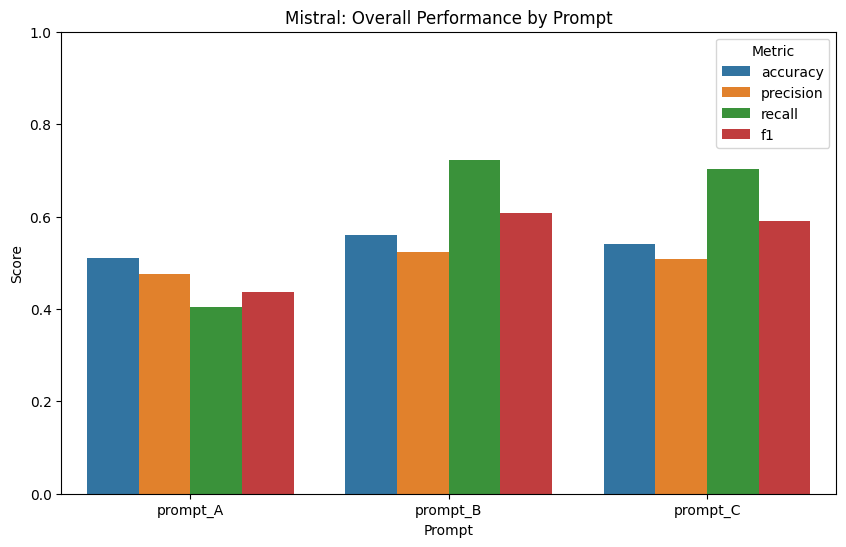

In [ ]:
# Overall metrics by prompt
overall_results = []

for prompt_name in prompts.keys():
    valid = test_df[test_df[f"pred_{prompt_name}"].notna()].copy()

    y_true = valid["label"]
    y_pred = valid[f"pred_{prompt_name}"].astype(int)

    overall_results.append({
        "prompt": prompt_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    })

overall_results_df = pd.DataFrame(overall_results)
print(overall_results_df)

# Graphic design
overall_long = overall_results_df.melt(
    id_vars="prompt",
    value_vars=["accuracy", "precision", "recall", "f1"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=overall_long, x="prompt", y="score", hue="metric")
plt.title("Mistral: Overall Performance by Prompt")
plt.xlabel("Prompt")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.show()

     prompt length_group    recall
0  prompt_A        short  0.350000
1  prompt_A       medium  0.437500
2  prompt_A         long  0.454545
3  prompt_B        short  0.600000
4  prompt_B       medium  0.812500
5  prompt_B         long  0.818182
6  prompt_C        short  0.650000
7  prompt_C       medium  0.750000
8  prompt_C         long  0.727273


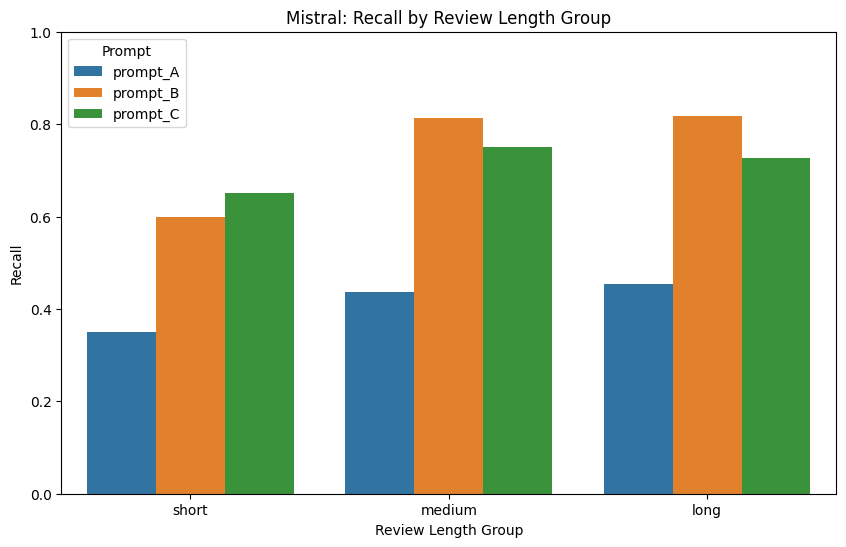

In [ ]:
# Recall by length group
length_results = []

for prompt_name in prompts.keys():
    for group in ["short", "medium", "long"]:
        subset = test_df[
            (test_df["length_group"] == group) &
            (test_df[f"pred_{prompt_name}"].notna())
        ].copy()

        if len(subset) == 0:
            rec = 0
        else:
            rec = recall_score(
                subset["label"],
                subset[f"pred_{prompt_name}"].astype(int),
                pos_label=1,
                zero_division=0
            )

        length_results.append({
            "prompt": prompt_name,
            "length_group": group,
            "recall": rec
        })

length_results_df = pd.DataFrame(length_results)
print(length_results_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=length_results_df, x="length_group", y="recall", hue="prompt")
plt.title("Mistral: Recall by Review Length Group")
plt.xlabel("Review Length Group")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.legend(title="Prompt")
plt.show()

###### 4.2.4.1. Stability Analysis

To assess the consistency of the model, we compute the disagreement rate between different prompt formulations. A disagreement occurs when at least one prompt produces a different prediction for the same review.

In [ ]:
test_df["prompt_disagreement"] = (
    (test_df["pred_prompt_A"] != test_df["pred_prompt_B"]) |
    (test_df["pred_prompt_A"] != test_df["pred_prompt_C"]) |
    (test_df["pred_prompt_B"] != test_df["pred_prompt_C"])
)

In [ ]:
change_rate = test_df["prompt_disagreement"].mean()

print("Prompt disagreement rate:", change_rate)

Prompt disagreement rate: 0.34


In [ ]:
test_df.groupby("length_group")["prompt_disagreement"].mean()

,prompt_disagreement
length_group,
long,0.448276
medium,0.354839
short,0.250000


  length_group  disagreement_rate
0         long           0.448276
1       medium           0.354839
2        short           0.250000


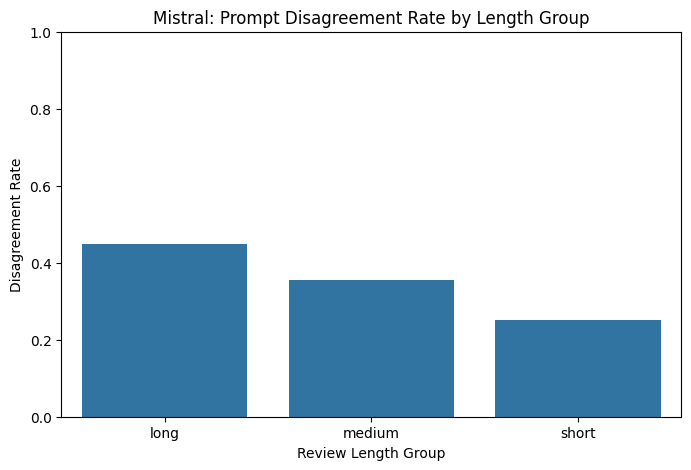

In [ ]:
# Prompt disagreement rate by length group
test_df["prompt_disagreement"] = (
    (test_df["pred_prompt_A"] != test_df["pred_prompt_B"]) |
    (test_df["pred_prompt_A"] != test_df["pred_prompt_C"]) |
    (test_df["pred_prompt_B"] != test_df["pred_prompt_C"])
)

disagreement_df = (
    test_df.groupby("length_group", as_index=False)["prompt_disagreement"]
    .mean()
    .rename(columns={"prompt_disagreement": "disagreement_rate"})
)

print(disagreement_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=disagreement_df, x="length_group", y="disagreement_rate")
plt.title("Mistral: Prompt Disagreement Rate by Length Group")
plt.xlabel("Review Length Group")
plt.ylabel("Disagreement Rate")
plt.ylim(0, 1)
plt.show()

The following examples illustrate cases where different prompts lead to different predictions for the same review.

In [ ]:
test_df[test_df["prompt_disagreement"]].head(5)

,text,label,n_tokens,length_group,raw_prompt_A,pred_prompt_A,raw_prompt_B,pred_prompt_B,raw_prompt_C,pred_prompt_C,prompt_disagreement
2,Update 11/28/2015 - Almost 2 years later and t...,0,140,long,REAL,0,FAKE,1,FAKE,1,True
3,"I bought this in November, 2011. It worked fan...",0,170,long,REAL,0,FAKE,1,FAKE,1,True
4,I used to buy and play with only brand-new bal...,0,511,long,REAL,0,FAKE,1,FAKE,1,True
5,"These are for a 13 yr old boy, needs for snow,...",1,38,short,REAL,0,FAKE,1,FAKE,1,True
8,"i really like this ink, it fills in very well ...",0,27,short,REAL,0,FAKE,1,FAKE,1,True


##### 4.2.4.2. Error Analysis

Errors in prompt A

In [ ]:
errors_A = test_df[test_df["pred_prompt_A"] != test_df["label"]]
errors_A[["text", "label", "raw_prompt_A", "pred_prompt_A"]].head(10)

,text,label,raw_prompt_A,pred_prompt_A
5,"These are for a 13 yr old boy, needs for snow,...",1,REAL,0
9,I suspect that my building is tilted because m...,0,FAKE,1
10,I use it for my podcast and voiceover work. Ve...,1,REAL,0
11,the mitts are truly great! I bought two of the...,0,FAKE,1
13,The manual is very good at explaining the vari...,1,REAL,0
14,This is essential for isolated houses. We have...,1,REAL,0
16,My remote control car is pretty cool. My favor...,1,REAL,0
17,Product is of poor quality and does not work. ...,1,REAL,0
19,I purchased this bag to use as my summer purse...,1,REAL,0
20,One of my dogs has sensitive skin and was itch...,1,REAL,0


In [ ]:
#Cases when all the prompts are mistaken
all_wrong = test_df[
    (test_df["pred_prompt_A"] != test_df["label"]) &
    (test_df["pred_prompt_B"] != test_df["label"]) &
    (test_df["pred_prompt_C"] != test_df["label"])
]

all_wrong[
    ["text", "label", "pred_prompt_A", "pred_prompt_B", "pred_prompt_C"]
].head(10)

,text,label,pred_prompt_A,pred_prompt_B,pred_prompt_C
9,I suspect that my building is tilted because m...,0,1,1,1
10,I use it for my podcast and voiceover work. Ve...,1,0,0,0
11,the mitts are truly great! I bought two of the...,0,1,1,1
14,This is essential for isolated houses. We have...,1,0,0,0
23,What a fantastic concert. Set list is just per...,0,1,1,1
24,"Guys, just buy this. It will make your wife ha...",0,1,1,1
27,I bought these earings as a Christmas gift for...,0,1,1,1
29,It came fast. I love the quality of the pictur...,0,1,1,1
35,I order regular and decaf coffee and mix them ...,0,1,1,1
37,Quality was much to be desire...treads was bro...,0,1,1,1


To better understand model behavior, we analyze misclassified examples and cases where prompts disagree. The analysis reveals several key patterns.

First, the model struggles with generic and vague reviews, which often lack specific product details. These reviews are frequently misclassified, as they provide limited information for reliable classification.

Second, some fake reviews closely resemble genuine user experiences, including specific use cases, making them difficult to distinguish from real reviews.

Additionally, errors are more frequent in longer reviews, which tend to introduce more ambiguity and mixed signals. This is consistent with the higher disagreement rate observed for long texts.

Finally, the results show that predictions are highly sensitive to prompt formulation, as different prompts often lead to different classifications for the same review.

##4.3. Qwen Model 3.5

In [ ]:
test_qwen = pd.DataFrame(ds["test"])
print("Test DataFrame shape:", test_qwen.shape)
test_qwen.head(3)

Test DataFrame shape: (2098, 4)


,text,label,n_tokens,length_group
0,I bought this at a local mart store for under ...,0,148,long
1,So bad experience. Got defected unit and they ...,1,73,long
2,Update 11/28/2015 - Almost 2 years later and t...,0,140,long


In [ ]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

QWEN_MODEL = "Qwen/Qwen3.5-9B"

quant_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

print(f"Loading tokenizer: {QWEN_MODEL}")
qwen_tok = AutoTokenizer.from_pretrained(QWEN_MODEL)

if qwen_tok.pad_token is None:
    qwen_tok.pad_token = qwen_tok.eos_token

print(f"Loading model (4-bit NF4): {QWEN_MODEL}")
qwen_model = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL,
    quantization_config=quant_cfg,
    device_map="auto",
    low_cpu_mem_usage=True,
)

qwen_model.eval()
print("\n✓ Model loaded successfully.")

Loading tokenizer: Qwen/Qwen3.5-9B


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]


✓ Model loaded successfully.


In [ ]:
SYSTEM_MSG = (
    "You are an expert classifier for fake product reviews. "
    "You may think internally, but your final response must end with exactly one line in this format: "
    "FINAL_LABEL: FAKE or FINAL_LABEL: REAL. "
    "Do not end with anything else after that final line."
)




PROMPT_A = """Classify this product review as FAKE or REAL.

A REAL review usually reflects genuine product experience, including concrete details, natural wording, or personal usage.
A FAKE review often relies on vague praise, exaggerated enthusiasm, or promotional language without clear evidence of real use.

Output exactly one word:
FAKE
or
REAL

Review:
{review}
"""

PROMPT_B = """Classify this product review as FAKE or REAL.

Consider whether it reflects genuine product experience or vague promotional language.

Output exactly one word:
FAKE
or
REAL

Review:
{review}
"""

PROMPT_C = """Classify this product review as FAKE or REAL.

Use cues such as specific experience, vague praise, and promotional wording.

Output exactly one word:
FAKE
or
REAL

Review:
{review}
"""


PROMPT_D = """You are a fraud detection expert specialised in e-commerce review authenticity.

Classify the review as FAKE or REAL.

Output exactly one word:
FAKE
or
REAL

Review:
{review}
"""

PROMPT_E = """Read the product review below and decide whether it sounds genuine or fabricated.

Return your final decision on the last line exactly as:
FINAL_LABEL: FAKE
or
FINAL_LABEL: REAL

Review:
{review}
"""

PROMPTS = {
    "prompt_A": PROMPT_A,
    "prompt_B": PROMPT_B,
    "prompt_C": PROMPT_C,
    "prompt_D": PROMPT_D,
    "prompt_E": PROMPT_E,
}

print(f"✓ {len(PROMPTS)} prompts defined.")

✓ 5 prompts defined.


In [ ]:
def parse_output(text: str):
    if text is None:
        return None

    t = text.strip().upper()

    # Best case: explicit final label
    m = re.search(r"FINAL_LABEL:\s*(FAKE|REAL)", t)
    if m:
        return 1 if m.group(1) == "FAKE" else 0

    # Fallback: last FAKE/REAL mention anywhere
    hits = re.findall(r"\b(FAKE|REAL)\b", t)
    if hits:
        return 1 if hits[-1] == "FAKE" else 0

    if any(w in t for w in ["DECEPTIVE", "FRAUDULENT", "FABRICATED", "INAUTHENTIC"]):
        return 1
    if any(w in t for w in ["GENUINE", "AUTHENTIC", "LEGITIMATE"]):
        return 0

    return None


def classify_review(review_text: str, prompt_template: str,
                    max_input_length: int = 1024, max_new_tokens: int = 120):
    prompt = prompt_template.format(review=review_text)

    messages = [
        {"role": "system", "content": SYSTEM_MSG},
        {"role": "user", "content": prompt},
    ]

    formatted = qwen_tok.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    try:
        inputs = qwen_tok(
            formatted,
            return_tensors="pt",
            truncation=True,
            max_length=max_input_length
        ).to(qwen_model.device)

        with torch.no_grad():
            out = qwen_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=qwen_tok.eos_token_id,
            )

        new_tokens = out[0][inputs["input_ids"].shape[1]:]
        raw = qwen_tok.decode(new_tokens, skip_special_tokens=True).strip()
        parsed = parse_output(raw)

        return raw, parsed

    except Exception as e:
        print(f"[ERROR] {e}")
        return None, None


In [ ]:
sample_text = test_qwen.iloc[0]["text"]
raw_out, parsed = classify_review(sample_text, PROMPT_E)

print("Sanity check (Prompt E)")
print("Review (first 200 chars):", sample_text[:200])
print(f"Model output: {raw_out!r} -> parsed: {parsed}")

assert parsed is not None, "Sanity check FAILED — check model output above."
print("✓ Sanity check passed.")

Sanity check (Prompt E)
Review (first 200 chars): I bought this at a local mart store for under six bucks. It's a nice sized bottle of make up remover and really does take off make up that other removers leave behind. I only use the "stay-put paint-o
Model output: 'Thinking Process:\n\n1.  **Analyze the Request:**\n    *   Task: Classify a product review as FAKE or REAL.\n    *   Input: A specific product review text.\n    *   Constraint: The final response must end with exactly one line in the format `FINAL_LABEL: FAKE` or `FINAL_LABEL: REAL`. No other text after that line.\n\n2.  **Analyze the Review Text:**\n    *   "I bought this at a local mart store for under six bucks." (Specific price point, specific store type).' -> parsed: 1
✓ Sanity check passed.


In [ ]:
RUN_FULL = False
N_PER_GROUP = 33

short_df = test_qwen[test_qwen["length_group"] == "short"].sample(n=33, random_state=42)
medium_df = test_qwen[test_qwen["length_group"] == "medium"].sample(n=33, random_state=42)
long_df = test_qwen[test_qwen["length_group"] == "long"].sample(n=34, random_state=42)

eval_df = pd.concat([short_df, medium_df, long_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print(eval_df["length_group"].value_counts())


for prompt_name, prompt_template in PROMPTS.items():
    print(f"\n{'='*60}")
    print(f"Prompt: {prompt_name}")
    print(f"{'='*60}")

    raw_col = f"raw_{prompt_name}"
    pred_col = f"pred_{prompt_name}"
    raws, preds, failed = [], [], 0
    ckpt = f"/content/qwen_{prompt_name}_checkpoint.csv"

    for i, review in enumerate(tqdm(eval_df["text"], desc=prompt_name)):
        raw, label = classify_review(review, prompt_template)
        raws.append(raw)
        preds.append(label)

        if label is None:
            failed += 1

        if (i + 1) % 200 == 0 or (i + 1) == len(eval_df):
            tmp = eval_df.iloc[: i + 1].copy()
            tmp[raw_col] = raws
            tmp[pred_col] = preds
            tmp.to_csv(ckpt, index=False)
            print(f"Checkpoint: {i+1}/{len(eval_df)} | failed: {failed}")

    eval_df[raw_col] = raws
    eval_df[pred_col] = preds
    print(f"✓ Done — total failed: {failed}/{len(eval_df)}")

Evaluating 100 reviews.
length_group
long      34
medium    33
short     33
Name: count, dtype: int64

Prompt: prompt_A


prompt_A:   0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
print("\n" + "="*60)
print("OVERALL METRICS — Qwen3.5-9B Zero-Shot (5 prompts)")
print("="*60)

overall_rows = []

for prompt_name in PROMPTS:
    pred_col = f"pred_{prompt_name}"
    valid = eval_df.dropna(subset=[pred_col]).copy()
    valid[pred_col] = valid[pred_col].astype(int)

    y_true = valid["label"]
    y_pred = valid[pred_col]

    row = {
        "prompt": prompt_name,
        "n_valid": len(valid),
        "n_failed": len(eval_df) - len(valid),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
    }
    overall_rows.append(row)

    print(f"\n── {prompt_name} ──")
    print(classification_report(y_true, y_pred, target_names=["Real", "Fake"], zero_division=0))

overall_df = pd.DataFrame(overall_rows)

print("\n=== Summary Table ===")
print(overall_df.to_string(index=False))

In [ ]:
group_rows = []

for prompt_name in PROMPTS:
    pred_col = f"pred_{prompt_name}"
    for group in ["short", "medium", "long"]:
        sub = eval_df[
            (eval_df["length_group"] == group) &
            (eval_df[pred_col].notna())
        ].copy()

        if len(sub) == 0:
            continue

        sub[pred_col] = sub[pred_col].astype(int)

        y_true = sub["label"]
        y_pred = sub[pred_col]

        group_rows.append({
            "prompt": prompt_name,
            "length_group": group,
            "n": len(sub),
            "accuracy": round(accuracy_score(y_true, y_pred), 4),
            "precision": round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
            "recall": round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
            "f1": round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        })

group_df = pd.DataFrame(group_rows)

print("=== Metrics by Length Group ===")
print(group_df.to_string(index=False))

In [ ]:
best_prompt = overall_df.loc[overall_df["f1"].idxmax(), "prompt"]
print(f"Best prompt by F1: {best_prompt}")

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, prompt_name in zip(axes, PROMPTS):
    pred_col = f"pred_{prompt_name}"
    valid = eval_df.dropna(subset=[pred_col]).copy()
    valid[pred_col] = valid[pred_col].astype(int)

    cm = confusion_matrix(valid["label"], valid[pred_col])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    title = prompt_name + (" ★ Best" if prompt_name == best_prompt else "")
    ax.set_title(title, fontsize=11)

plt.suptitle("Qwen3.5-9B Zero-Shot — Confusion Matrices (5 Prompts)", fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig("/content/qwen_confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: /content/qwen_confusion_matrices.png")

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
bar_w = 0.14
x = np.arange(3)
groups = ["short", "medium", "long"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

for idx, prompt_name in enumerate(PROMPTS):
    recalls = []
    for g in groups:
        row = group_df[(group_df["prompt"] == prompt_name) & (group_df["length_group"] == g)]
        recalls.append(row["recall"].values[0] if len(row) > 0 else 0.0)

    offset = (idx - 2) * bar_w
    ax.bar(x + offset, recalls, width=bar_w, label=prompt_name,
           color=colors[idx], alpha=0.85, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(["Short (≤42 tok)", "Medium (43–71 tok)", "Long (>71 tok)"], fontsize=11)
ax.set_ylabel("Recall (Fake = 1)", fontsize=11)
ax.set_title("Qwen3.5-9B Zero-Shot: Recall by Prompt × Length Group", fontsize=13)
ax.legend(title="Prompt", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig("/content/qwen_recall_by_length.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: /content/qwen_recall_by_length.png")

In [ ]:
pred_cols = [f"pred_{p}" for p in PROMPTS]

complete = eval_df.dropna(subset=pred_cols).copy()

for c in pred_cols:
    complete[c] = complete[c].astype(int)

complete["prompt_disagreement"] = complete[pred_cols].nunique(axis=1) > 1

overall_dis = complete["prompt_disagreement"].mean()
print(f"Overall prompt disagreement rate: {overall_dis:.3f}")

dis_by_len = complete.groupby("length_group")["prompt_disagreement"].mean()
print("\nDisagreement by length group:")
print(dis_by_len.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
dis_by_len.reindex(["short", "medium", "long"]).plot(
    kind="bar",
    ax=ax,
    color=["#4C72B0", "#DD8452", "#55A868"],
    edgecolor="black",
    alpha=0.85
)

ax.set_xticklabels(["Short", "Medium", "Long"], rotation=0, fontsize=11)
ax.set_ylabel("Disagreement Rate", fontsize=11)
ax.set_title("Prompt Disagreement Rate by Length Group\n(Qwen3.5-9B, 5 prompts)", fontsize=12)
ax.set_ylim(0, 1)
ax.axhline(overall_dis, color="red", linestyle="--", linewidth=1, label=f"Overall ({overall_dis:.2f})")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("/content/qwen_disagreement_by_length.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: /content/qwen_disagreement_by_length.png")

print("Sample reviews where prompts disagree:")
display_cols = ["text", "label", "length_group"] + pred_cols
print(complete[complete["prompt_disagreement"]][display_cols].head(5).to_string())

In [ ]:
overall_df.to_csv("/content/qwen_overall_metrics.csv", index=False)
group_df.to_csv("/content/qwen_group_metrics.csv", index=False)
complete.to_csv("/content/qwen_all_predictions.csv", index=False)

print("Results saved to /content/:")
print("  qwen_overall_metrics.csv")
print("  qwen_group_metrics.csv")
print("  qwen_all_predictions.csv")

DRIVE_DIR = "/content/drive/MyDrive/DATA6400_Qwen_ZeroShot"
os.makedirs(DRIVE_DIR, exist_ok=True)

overall_df.to_csv(f"{DRIVE_DIR}/qwen_overall_metrics.csv", index=False)
group_df.to_csv(f"{DRIVE_DIR}/qwen_group_metrics.csv", index=False)
complete.to_csv(f"{DRIVE_DIR}/qwen_all_predictions.csv", index=False)

import shutil
for fname in ["qwen_confusion_matrices.png", "qwen_recall_by_length.png", "qwen_disagreement_by_length.png"]:
    src = f"/content/{fname}"
    if os.path.exists(src):
        shutil.copy(src, f"{DRIVE_DIR}/{fname}")

print("Results also saved to Google Drive:", DRIVE_DIR)

In [ ]:
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"Model        : {QWEN_MODEL}")
print(f"Quantization : 4-bit NF4 (bitsandbytes)")
print(f"Test set     : {len(eval_df)} reviews")
print(f"Prompts      : {len(PROMPTS)}")
print()

print("Overall metrics:")
print(overall_df[["prompt", "accuracy", "precision", "recall", "f1"]].to_string(index=False))
print()

print("Best prompt by F1    :", overall_df.loc[overall_df["f1"].idxmax(), "prompt"])
print("Best prompt by Recall:", overall_df.loc[overall_df["recall"].idxmax(), "prompt"])
print()

## 5. Comparative Results

In [3]:
results_table = pd.DataFrame({
    "Model": [
        "RoBERTa",
        "Mistral Prompt A",
        "Mistral Prompt B",
        "Mistral Prompt C",
        "Qwen Prompt A",
        "Qwen Prompt B",
        "Qwen Prompt C",
        "Qwen Prompt D",
        "Qwen Prompt E",
    ],
    "Accuracy": [0.79, 0.51, 0.56, 0.54, 0.44, 0.40, 0.56,0.46,0.49],
    "Precision": [0.70, 0.48, 0.52, 0.51, 0.44, 0.41, 0.53, 0.47, 0.48],
    "Recall": [0.77, 0.40, 0.72, 0.70, 0.72, 0.62, 0.64, 0.87, 1.00],
    "F1": [0.73, 0.44, 0.61, 0.59, 0.55, 0.49, 0.58, 0.60, 0.65]
})

results_table

,Model,Accuracy,Precision,Recall,F1
0,RoBERTa,0.79,0.70,0.77,0.73
1,Mistral Prompt A,0.51,0.48,0.40,0.44
2,Mistral Prompt B,0.56,0.52,0.72,0.61
3,Mistral Prompt C,0.54,0.51,0.70,0.59
4,Qwen Prompt A,0.44,0.44,0.72,0.55
5,Qwen Prompt B,0.40,0.41,0.62,0.49
6,Qwen Prompt C,0.56,0.53,0.64,0.58
7,Qwen Prompt D,0.46,0.47,0.87,0.60
8,Qwen Prompt E,0.49,0.48,1.00,0.65


In [4]:
length_results_table = pd.DataFrame({
    "Model": [
        "RoBERTa",
        "Mistral Prompt A",
        "Mistral Prompt B",
        "Mistral Prompt C",
        "Qwen Prompt A",
        "Qwen Prompt B",
        "Qwen Prompt C",
        "Qwen Prompt D",
        "Qwen Prompt E",
    ],
    "Short": [0.72, 0.35, 0.60, 0.65, 0.65, 0.55, 0.69, 0.78, 1.00],
    "Medium": [0.83, 0.44, 0.81, 0.75, 0.78, 0.62, 0.84, 0.90, 1.00],
    "Long": [0.73, 0.45, 0.82, 0.73, 0.74, 0.68, 0.71, 1.00, 1.00]
})

length_results_table

,Model,Short,Medium,Long
0,RoBERTa,0.72,0.83,0.73
1,Mistral Prompt A,0.35,0.44,0.45
2,Mistral Prompt B,0.60,0.81,0.82
3,Mistral Prompt C,0.65,0.75,0.73
4,Qwen Prompt A,0.65,0.78,0.74
5,Qwen Prompt B,0.55,0.62,0.68
6,Qwen Prompt C,0.69,0.84,0.71
7,Qwen Prompt D,0.78,0.90,1.00
8,Qwen Prompt E,1.00,1.00,1.00
